# Aceleración con LCM-LoRA (Latent Consistency Models)

**Módulo Complementario: Difusión Generativa 2025**

**IFTS24 - Prof. Matias Barreto**

---

## Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:
- Acelerar cualquier modelo de difusión con LCM-LoRA
- Comprender qué son los LoRAs y cómo funcionan
- Reducir pasos de inferencia sin pérdida de calidad
- Aplicar LoRAs a diferentes modelos base
- Combinar múltiples LoRAs

---

## ¿Qué es LCM-LoRA?

**LCM (Latent Consistency Model)** es una técnica que permite generar imágenes de calidad en solo **4-8 pasos** en lugar de 20-50.

**LoRA (Low-Rank Adaptation)** es un método eficiente para agregar capacidades a modelos sin reentrenarlos completamente.

**LCM-LoRA** combina ambas técnicas: es un archivo pequeño (~200 MB) que podés cargar sobre cualquier modelo Stable Diffusion para acelerarlo.

**Características principales:**
- **Universal**: Funciona con SDXL, SD 1.5, y variantes
- **Pequeño**: ~200 MB vs múltiples GB del modelo completo
- **Plug-and-play**: Cargás el LoRA y listo
- **Combinar**: Podés usar múltiples LoRAs simultáneamente
- **Velocidad**: 4-8 pasos vs 20-50 pasos tradicionales

**Requisitos:**
- Modelo base compatible (SDXL, SD 1.5, etc.)
- 4-8 GB RAM/VRAM según el modelo base

---

## 1. Verificación de Hardware

In [ ]:
import torch
import sys

print("=== Verificación de Hardware ===")
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Memoria GPU: {gpu_memory:.2f} GB")
    device = "cuda"

    if gpu_memory >= 6:
        modelo_recomendado = "SDXL + LCM-LoRA"
    else:
        modelo_recomendado = "SD 1.5 + LCM-LoRA"

    print(f"\n✅ Recomendación: {modelo_recomendado}")
else:
    print("\nSin GPU detectada")
    device = "cpu"
    print("Recomendación: SD 1.5 + LCM-LoRA en CPU (más lento)")

print(f"\nDispositivo a usar: {device}")

=== Verificación de Hardware ===
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.8.0+cu126
CUDA disponible: True

GPU: Tesla T4
Memoria GPU: 15.83 GB

✅ Recomendación: SDXL + LCM-LoRA

Dispositivo a usar: cuda


---

## 2. Instalación de Dependencias

📌 **IMPORTANTE:** Necesitamos diffusers actualizado con soporte para LoRA.

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Instalando dependencias en Google Colab...")
    !pip install -q -U diffusers[torch] transformers accelerate safetensors
    print("✅ Instalación completada")
else:
    print("Entorno local. Asegúrate de tener diffusers >= 0.28.0")
    print("Comando: pip install -U diffusers transformers")

Instalando dependencias en Google Colab...
✅ Instalación completada


---

## 3. Importación de Bibliotecas

In [ ]:
import torch
from diffusers import DiffusionPipeline, LCMScheduler
from PIL import Image
import matplotlib.pyplot as plt
import time
from datetime import datetime
import os

print("✅ Bibliotecas importadas correctamente")

✅ Bibliotecas importadas correctamente


---

## 4. Carga del Modelo Base + LCM-LoRA

Vamos a cargar SDXL y luego aplicarle el LoRA de aceleración.

In [ ]:
# Configuración
model_id = "stabilityai/stable-diffusion-xl-base-1.0"
lcm_lora_id = "latent-consistency/lcm-lora-sdxl"

print(f"Cargando modelo base: {model_id}")
print("Esto puede tardar algunos minutos la primera vez...\n")

# Cargar pipeline base
pipe = DiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16" if device == "cuda" else None,
)

pipe = pipe.to(device)

print("✅ Modelo base cargado")
print(f"\nCargando LCM-LoRA: {lcm_lora_id}")

# Cargar LCM-LoRA
pipe.load_lora_weights(lcm_lora_id)

# Cambiar scheduler a LCM
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

print("✅ LCM-LoRA cargado y configurado")

# Optimizaciones de memoria
if device == "cuda":
    pipe.enable_attention_slicing()
    pipe.enable_vae_slicing()
    print("✅ Optimizaciones de memoria aplicadas")

Cargando modelo base: stabilityai/stable-diffusion-xl-base-1.0
Esto puede tardar algunos minutos la primera vez...



model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Modelo base cargado

Cargando LCM-LoRA: latent-consistency/lcm-lora-sdxl


pytorch_lora_weights.safetensors:   0%|          | 0.00/394M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


✅ LCM-LoRA cargado y configurado
✅ Optimizaciones de memoria aplicadas


---

## 5. Comparación: Con vs Sin LCM-LoRA

Vamos a comparar la velocidad y calidad con diferentes números de pasos.

Generando con diferentes números de pasos...
Prompt: A beautiful landscape with mountains and a lake, sunset, highly detailed

Generando: 4 pasos (LCM)


  0%|          | 0/4 [00:00<?, ?it/s]

  ⏱️ Tiempo: 6.71s

Generando: 8 pasos (LCM)


  0%|          | 0/8 [00:00<?, ?it/s]

  ⏱️ Tiempo: 6.76s



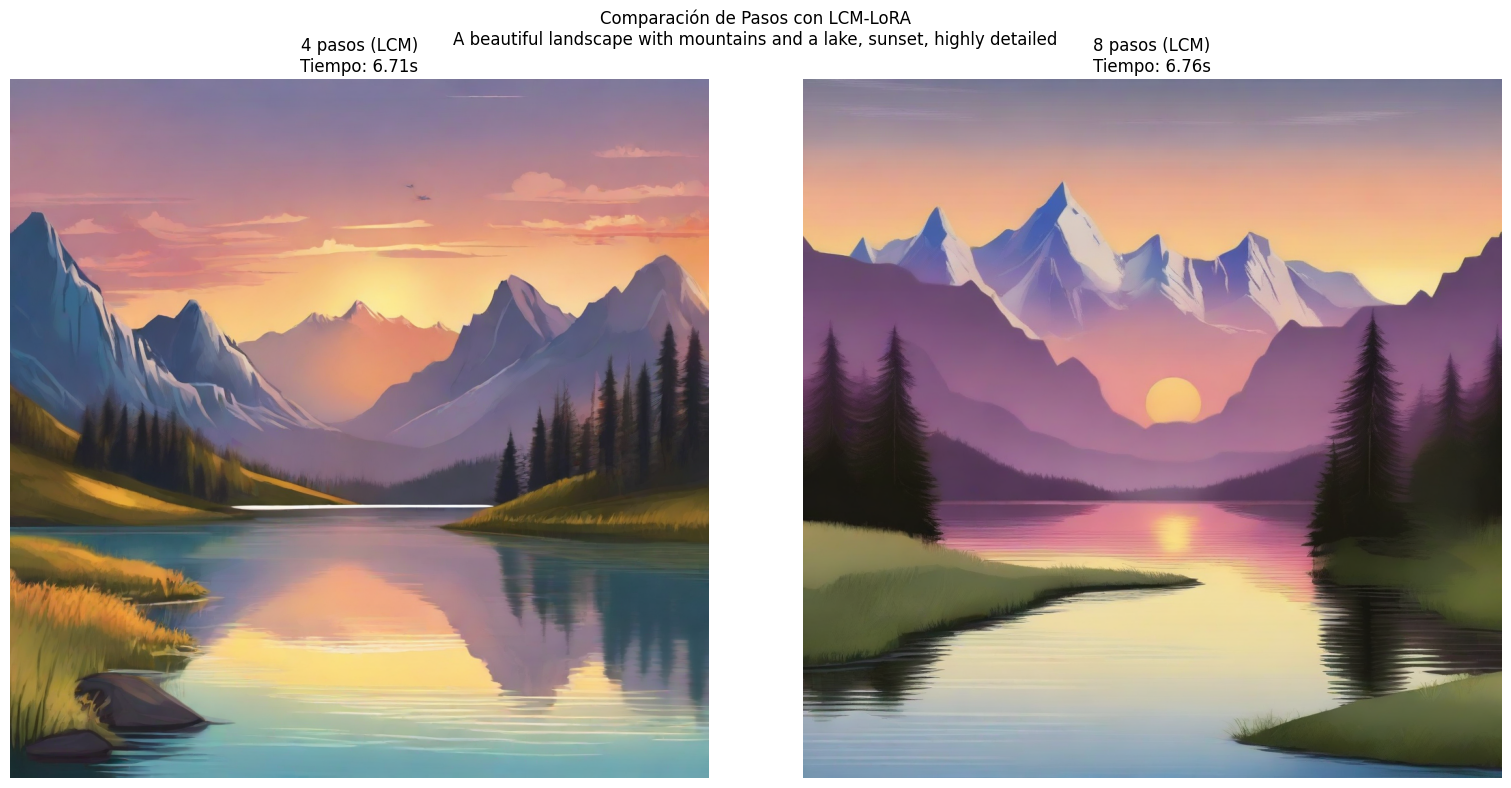

💡 TIP: Con LCM-LoRA, 4-8 pasos suelen ser suficientes


In [ ]:
# Prompt de prueba
prompt = "A beautiful landscape with mountains and a lake, sunset, highly detailed"

print(f"Generando con diferentes números de pasos...")
print(f"Prompt: {prompt}\n")

# Diferentes configuraciones a probar
configs = [
    (4, "4 pasos (LCM)"),
    (8, "8 pasos (LCM)"),
]

fig, axes = plt.subplots(1, len(configs), figsize=(16, 8))

for idx, (steps, label) in enumerate(configs):
    print(f"Generando: {label}")

    start_time = time.time()

    image = pipe(
        prompt=prompt,
        num_inference_steps=steps,
        guidance_scale=1.0,  # LCM funciona mejor con guidance bajo
        height=1024,
        width=1024,
    ).images[0]

    elapsed = time.time() - start_time

    axes[idx].imshow(image)
    axes[idx].axis('off')
    axes[idx].set_title(f"{label}\nTiempo: {elapsed:.2f}s")

    print(f"  ⏱️ Tiempo: {elapsed:.2f}s\n")

plt.suptitle(f"Comparación de Pasos con LCM-LoRA\n{prompt}")
plt.tight_layout()
plt.show()

print("💡 TIP: Con LCM-LoRA, 4-8 pasos suelen ser suficientes")

---

## 6. Experimentación con Guidance Scale

LCM funciona mejor con valores de guidance_scale entre 1.0 y 2.0 (mucho menor que los tradicionales 7-15).

Probando diferentes valores de guidance_scale...
Prompt: A futuristic city with flying cars, cyberpunk style, neon lights

Generando con guidance_scale=1.0...


  0%|          | 0/4 [00:00<?, ?it/s]

Generando con guidance_scale=1.5...


  0%|          | 0/4 [00:00<?, ?it/s]

Generando con guidance_scale=2.0...


  0%|          | 0/4 [00:00<?, ?it/s]

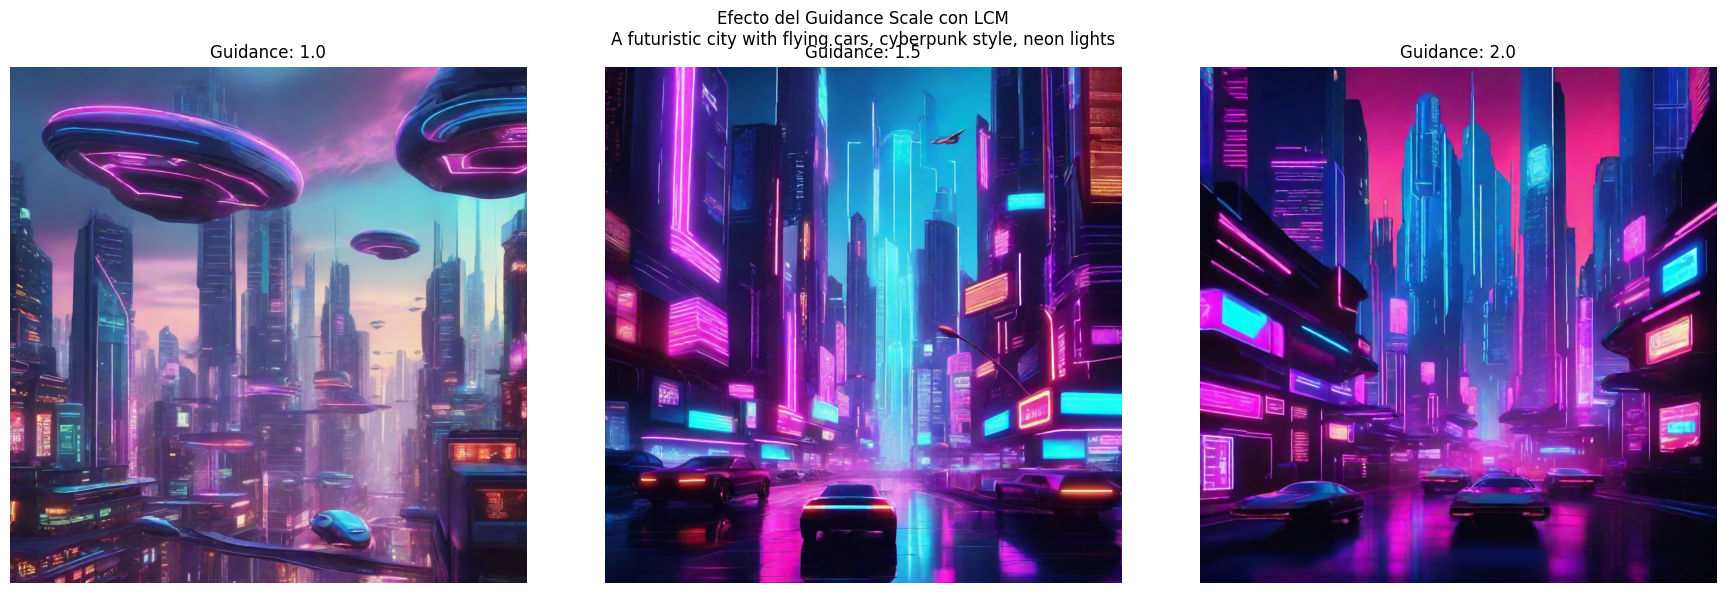


💡 TIP: Guidance más alto = más adherencia al prompt
Pero con LCM, valores >2.0 pueden degradar la calidad


In [ ]:
# Probar diferentes valores de guidance
prompt_guidance = "A futuristic city with flying cars, cyberpunk style, neon lights"
guidance_values = [1.0, 1.5, 2.0]

print(f"Probando diferentes valores de guidance_scale...")
print(f"Prompt: {prompt_guidance}\n")

fig, axes = plt.subplots(1, len(guidance_values), figsize=(18, 6))

for idx, guidance in enumerate(guidance_values):
    print(f"Generando con guidance_scale={guidance}...")

    image = pipe(
        prompt=prompt_guidance,
        num_inference_steps=4,
        guidance_scale=guidance,
        height=1024,
        width=1024,
    ).images[0]

    axes[idx].imshow(image)
    axes[idx].axis('off')
    axes[idx].set_title(f"Guidance: {guidance}")

plt.suptitle(f"Efecto del Guidance Scale con LCM\n{prompt_guidance}")
plt.tight_layout()
plt.show()

print("\n💡 TIP: Guidance más alto = más adherencia al prompt")
print("Pero con LCM, valores >2.0 pueden degradar la calidad")

---

## 7. Usando LCM-LoRA con SD 1.5

LCM-LoRA también funciona con Stable Diffusion 1.5, que es más liviano.

Cargando SD 1.5 + LCM-LoRA...



model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

pytorch_lora_weights.safetensors:   0%|          | 0.00/135M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ SD 1.5 + LCM-LoRA listo

Generando con SD 1.5...
Prompt: A serene japanese garden with cherry blossoms, koi pond, traditional architecture



  0%|          | 0/4 [00:00<?, ?it/s]

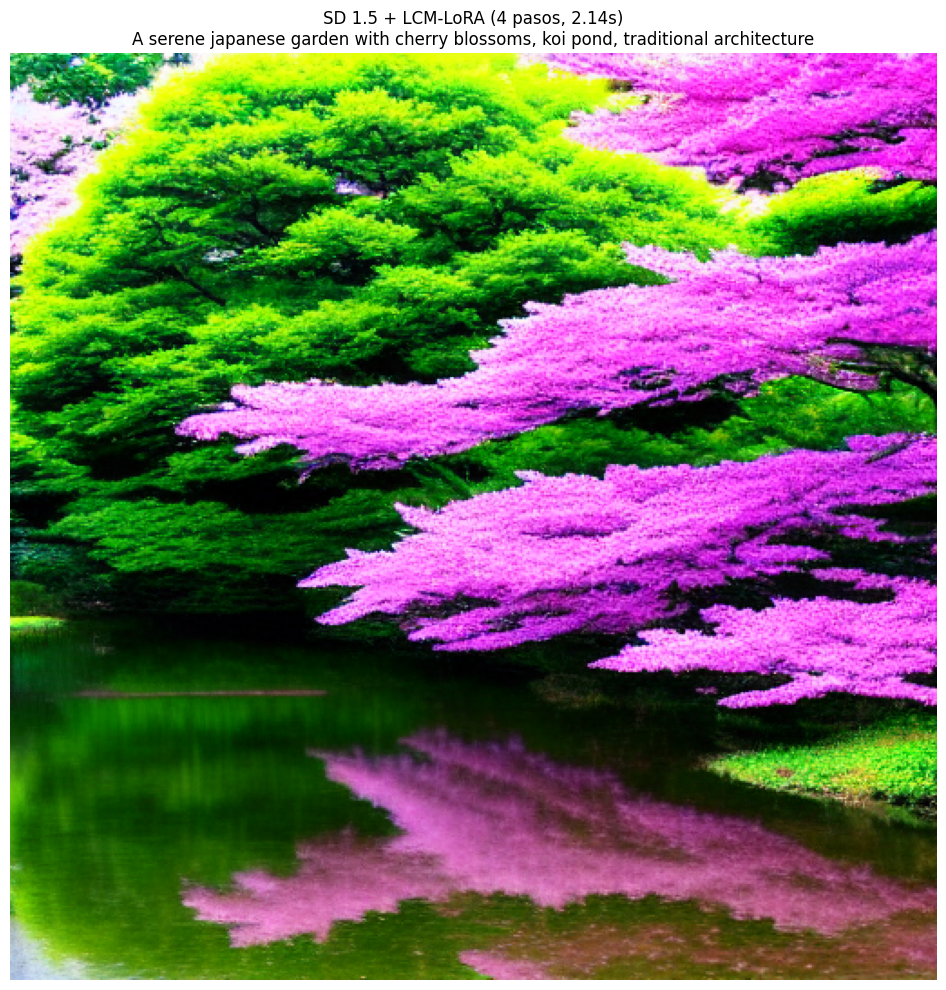


✅ Imagen generada en 2.14s
💡 TIP: SD 1.5 es más rápido y usa menos memoria que SDXL


In [ ]:
# Cargar SD 1.5 con LCM-LoRA (más liviano que SDXL)
print("Cargando SD 1.5 + LCM-LoRA...\n")

pipe_sd15 = DiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)

pipe_sd15 = pipe_sd15.to(device)

# Cargar LCM-LoRA para SD 1.5
pipe_sd15.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
pipe_sd15.scheduler = LCMScheduler.from_config(pipe_sd15.scheduler.config)

if device == "cuda":
    pipe_sd15.enable_attention_slicing()
    pipe_sd15.enable_vae_slicing()

print("✅ SD 1.5 + LCM-LoRA listo")

# Generar imagen
prompt_sd15 = "A serene japanese garden with cherry blossoms, koi pond, traditional architecture"

print(f"\nGenerando con SD 1.5...")
print(f"Prompt: {prompt_sd15}\n")

start = time.time()

image_sd15 = pipe_sd15(
    prompt=prompt_sd15,
    num_inference_steps=4,
    guidance_scale=1.0,
    height=512,
    width=512,
).images[0]

elapsed = time.time() - start

plt.figure(figsize=(10, 10))
plt.imshow(image_sd15)
plt.axis('off')
plt.title(f"SD 1.5 + LCM-LoRA (4 pasos, {elapsed:.2f}s)\n{prompt_sd15}")
plt.tight_layout()
plt.show()

print(f"\n✅ Imagen generada en {elapsed:.2f}s")
print("💡 TIP: SD 1.5 es más rápido y usa menos memoria que SDXL")

---

## 8. Combinando Múltiples LoRAs

Podés combinar LCM-LoRA con otros LoRAs de estilo.

In [ ]:
# Ejemplo: Combinar LCM con un LoRA de estilo
# (Esto es avanzado - requiere LoRAs compatibles)

print("💡 TIP: Combinación de LoRAs")
print("\nPodés cargar múltiples LoRAs simultáneamente:")
print("""
# Cargar primer LoRA (LCM)
pipe.load_lora_weights("latent-consistency/lcm-lora-sdxl")

# Cargar segundo LoRA (ej: estilo)
pipe.load_lora_weights(
    "nombre-del-lora-de-estilo",
    adapter_name="style"
)

# Activar ambos con pesos
pipe.set_adapters(["default", "style"], adapter_weights=[1.0, 0.8])
""")

print("\n⚠️ Nota: Los LoRAs deben ser compatibles con el mismo modelo base")
print("Buscá LoRAs en: https://huggingface.co/models?other=lora")

💡 TIP: Combinación de LoRAs

Podés cargar múltiples LoRAs simultáneamente:

# Cargar primer LoRA (LCM)
pipe.load_lora_weights("latent-consistency/lcm-lora-sdxl")

# Cargar segundo LoRA (ej: estilo)
pipe.load_lora_weights(
    "nombre-del-lora-de-estilo",
    adapter_name="style"
)

# Activar ambos con pesos
pipe.set_adapters(["default", "style"], adapter_weights=[1.0, 0.8])


⚠️ Nota: Los LoRAs deben ser compatibles con el mismo modelo base
Buscá LoRAs en: https://huggingface.co/models?other=lora


---

## 9. Descargar y Usar LoRAs de la Comunidad

Hay miles de LoRAs gratuitos disponibles en Hugging Face.

In [ ]:
# Ejemplo con un LoRA popular de estilo pixel art
# (Necesitás conexión a internet)

print("Ejemplo: Cargando LoRA de estilo pixel art...\n")

try:
    # Crear nuevo pipeline para no interferir con LCM
    pipe_style = DiffusionPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    )
    pipe_style = pipe_style.to(device)

    # Cargar LoRA de estilo (ejemplo)
    # Nota: Reemplazá esto con cualquier LoRA de HuggingFace
    lora_style_id = "nerijs/pixel-art-xl"  # Ejemplo de LoRA público

    pipe_style.load_lora_weights(lora_style_id)

    print(f"✅ LoRA de estilo cargado: {lora_style_id}")

    # Generar con el estilo
    prompt_style = "a medieval castle, pixel art style"

    image_style = pipe_style(
        prompt=prompt_style,
        num_inference_steps=20,
        guidance_scale=7.5,
    ).images[0]

    plt.figure(figsize=(10, 10))
    plt.imshow(image_style)
    plt.axis('off')
    plt.title(f"Con LoRA de Estilo\n{prompt_style}")
    plt.show()

except Exception as e:
    print(f"⚠️ Error cargando LoRA de ejemplo: {e}")
    print("\nEsto es normal si el LoRA específico no está disponible.")
    print("Podés buscar otros LoRAs en: https://huggingface.co/models?other=lora")

Ejemplo: Cargando LoRA de estilo pixel art...



Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

text_encoder_2/model.safetensors:   0%|          | 0.00/2.78G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.safetens(…):   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

⚠️ Error cargando LoRA de ejemplo: CUDA out of memory. Tried to allocate 26.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 14.12 MiB is free. Process 2702 has 14.72 GiB memory in use. Of the allocated memory 14.36 GiB is allocated by PyTorch, and 243.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Esto es normal si el LoRA específico no está disponible.
Podés buscar otros LoRAs en: https://huggingface.co/models?other=lora


---

## 10. Guardar Imágenes con Metadata de LoRA

In [ ]:
from PIL import PngImagePlugin

output_dir = "lcm_lora_generaciones"
os.makedirs(output_dir, exist_ok=True)

def guardar_con_lora_info(image, prompt, lora_name, steps, guidance, output_dir):
    """Guarda imagen con información del LoRA usado"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"lcm_{timestamp}.png"
    filepath = os.path.join(output_dir, filename)

    metadata = PngImagePlugin.PngInfo()
    metadata.add_text("prompt", prompt)
    metadata.add_text("lora", lora_name)
    metadata.add_text("steps", str(steps))
    metadata.add_text("guidance_scale", str(guidance))
    metadata.add_text("model", "SDXL + LCM-LoRA")
    metadata.add_text("timestamp", timestamp)

    image.save(filepath, pnginfo=metadata)

    return filepath

# Generar imagen final
prompt_final = "A mystical forest with glowing mushrooms and fireflies, magical atmosphere, highly detailed"

print(f"Generando imagen final...")
print(f"Prompt: {prompt_final}\n")

imagen_final = pipe(
    prompt=prompt_final,
    num_inference_steps=4,
    guidance_scale=1.0,
    height=1024,
    width=1024,
).images[0]

saved_path = guardar_con_lora_info(
    image=imagen_final,
    prompt=prompt_final,
    lora_name="LCM-LoRA-SDXL",
    steps=4,
    guidance=1.0,
    output_dir=output_dir
)

plt.figure(figsize=(12, 12))
plt.imshow(imagen_final)
plt.axis('off')
plt.title(f"Imagen Final con LCM-LoRA\n{prompt_final}")
plt.tight_layout()
plt.show()

print(f"\n✅ Imagen guardada en: {saved_path}")

---

## 💡 Ventajas y Limitaciones de LCM-LoRA

### Ventajas
✅ **Universal**: Funciona con múltiples modelos base
✅ **Pequeño**: Solo ~200 MB adicionales
✅ **Rápido**: 5-10x más rápido que generación tradicional
✅ **Plug-and-play**: No requiere reentrenamiento
✅ **Combinable**: Se puede usar con otros LoRAs

### Limitaciones
⚠️ Guidance scale debe ser bajo (1.0-2.0)
⚠️ Algunos detalles pueden perderse vs modelos completos
⚠️ No todos los LoRAs son compatibles entre sí
⚠️ Requiere scheduler específico (LCMScheduler)

---

## ✅ Ejercicios

### Ejercicio 1: Comparación directa
Generá la misma imagen con:
- SDXL sin LoRA (50 pasos)
- SDXL + LCM-LoRA (4 pasos)

Compará calidad y velocidad.

### Ejercicio 2: Optimización de guidance
Para un prompt complejo, probá guidance_scale de 0.5 a 2.5 en pasos de 0.5. ¿Cuál da mejor resultado?

### Ejercicio 3: SD 1.5 vs SDXL
Generá la misma escena con LCM-LoRA en ambos modelos. ¿Qué diferencias notás?

### Ejercicio 4: Búsqueda de LoRAs
Buscá 3 LoRAs de estilo en Hugging Face e intentá cargarlos (pueden necesitar modelos base diferentes).

---

## 🔍 Para Profundizar

**Recursos adicionales:**
- Paper de LCM: https://arxiv.org/abs/2310.04378
- LCM-LoRA SDXL: https://huggingface.co/latent-consistency/lcm-lora-sdxl
- LCM-LoRA SD1.5: https://huggingface.co/latent-consistency/lcm-lora-sdv1-5
- Buscar LoRAs: https://huggingface.co/models?other=lora

**Próximos pasos:**
- Para optimizaciones de memoria: `014_Optimizacion_Memoria_GPU.ipynb`
- Para aplicaciones prácticas: carpeta `03_Aplicaciones_Practicas/`
- Para crear tus propios LoRAs: Buscar tutoriales de fine-tuning

---

**¡Felicitaciones!** Ahora sabés acelerar cualquier modelo de difusión con LoRAs. 🚀